<a href="https://colab.research.google.com/github/Cristobal2506/MineriaDeDatos/blob/ENTREGA-3/Prueba_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPACTO DE LA IA EN LOS TRABAJOS
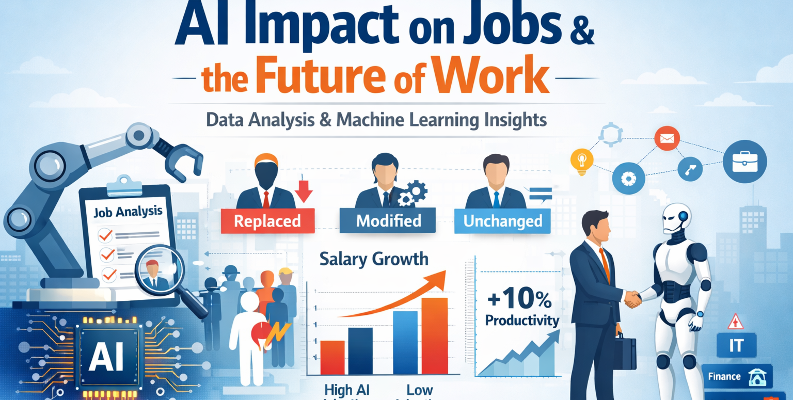

Integrante 1: Cristobal Muñoz cra.munozr@duocuc.cl

Integrante 2: Nixy Silva nix.silva@duocuc.cl

Seccion: 004D

Contexto: En la actualidad, la IA está cambiando la forma en la que se realizan muchas tareas en distintos tipos de trabajos. Gracias a avances tecnologicos como el Aprendizaje automatico, las maquinas pueden realizar actividades que antes solo hacian las personas, especialmente aquellas repetitivas o predecibles.

Esto ha generado consecuencias importantes en el empleo. Algunos trabajaos han sido reemplazados o modificados debido a a la automatización. Por otro lado, han surgido nuevas oportunidades laborales relacionadas con el desarrollo, uso y mantenimiento de estas mismas tecnologias.
En este contexto, analizar la informacion disponible permite comprender mejor estos cambios y anticipar como podrían evolucionar los trabajos en un futuro, ayudando a las personas y organizaciones a prepararse.


link dataset
https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector

In [ ]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              mean_absolute_percentage_error)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [ ]:
#importar el dataset
df = pd.read_csv("/content/ai_job_impact.csv")

In [ ]:
#indentificamos las columnas
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education_Level', 'Industry',
       'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk',
       'Upskilling_Required', 'Salary_Before_AI', 'Salary_After_AI',
       'Job_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Productivity_Change_%'],
      dtype='object')

In [ ]:
df.head(2001
        )

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31


In [ ]:
df.shape   #numero de filas y columnas validas

(2000, 17)

### Codificación de variables categóricas

Vamos a aplicar la técnica de one-hot encoding a las columnas 'Industry' y 'Job_Role' para convertirlas en un formato numérico que los modelos de machine learning puedan interpretar.

In [ ]:
# Aplicar One-Hot Encoding a las columnas 'Industry', 'Job_Role', 'Gender', 'Education_Level', 'AI_Adoption_Level', 'Automation_Risk', 'Upskilling_Required', 'Remote_Work', y 'Job_Status'
df_encoded = pd.get_dummies(df, columns=['Industry', 'Job_Role', 'Gender', 'Education_Level', 'AI_Adoption_Level', 'Automation_Risk', 'Upskilling_Required', 'Remote_Work', 'Job_Status'], drop_first=True)

print('Primeras 5 filas del DataFrame con columnas codificadas:')
display(df_encoded.head())

Primeras 5 filas del DataFrame con columnas codificadas:


,Employee_ID,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%,Industry_Finance,Industry_Healthcare,Industry_IT,Industry_Manufacturing,Industry_Marketing,Industry_Retail,Job_Role_Administrator,Job_Role_Auditor,Job_Role_Cashier,Job_Role_Content Creator,Job_Role_Data Analyst,Job_Role_DevOps Engineer,Job_Role_Digital Marketer,Job_Role_Doctor,Job_Role_Investment Analyst,Job_Role_Machine Operator,Job_Role_Nurse,Job_Role_Professor,Job_Role_Quality Inspector,Job_Role_SEO Specialist,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supervisor,Job_Role_Teacher,Job_Role_Technician,Gender_Male,Gender_Other,Education_Level_High School,Education_Level_Master,Education_Level_PhD,AI_Adoption_Level_Low,AI_Adoption_Level_Medium,Automation_Risk_Low,Automation_Risk_Medium,Upskilling_Required_Yes,Remote_Work_Yes,Job_Status_Replaced,Job_Status_Unchanged
0,E0001,50,26,106820,95455,45,5,-10.64,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,E0002,45,19,74131,72013,36,6,19.05,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,True,False,True
2,E0003,51,28,35311,42290,46,3,17.05,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,True,True,False,False
3,E0004,48,24,114478,107820,50,9,-2.47,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False,False
4,E0005,24,0,33890,40945,52,6,7.03,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False


In [ ]:
#Valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '-', df[feature].isna().sum())

Total de valores nulos de Employee_ID - 0
Total de valores nulos de Age - 0
Total de valores nulos de Gender - 0
Total de valores nulos de Education_Level - 0
Total de valores nulos de Industry - 0
Total de valores nulos de Job_Role - 0
Total de valores nulos de Years_Experience - 0
Total de valores nulos de AI_Adoption_Level - 0
Total de valores nulos de Automation_Risk - 0
Total de valores nulos de Upskilling_Required - 0
Total de valores nulos de Salary_Before_AI - 0
Total de valores nulos de Salary_After_AI - 0
Total de valores nulos de Job_Status - 0
Total de valores nulos de Work_Hours_Per_Week - 0
Total de valores nulos de Remote_Work - 0
Total de valores nulos de Job_Satisfaction - 0
Total de valores nulos de Productivity_Change_% - 0


como no hay valores nulos, continuamos


In [ ]:
df['Industry'].value_counts()

,count
Industry,
Finance,300
IT,298
Manufacturing,295
Education,293
Marketing,273
Retail,271
Healthcare,270


In [ ]:
#Selecciona solo las caracteristicas que se van a considerar en los posteriores analisis
X = df.iloc[:,[4,5,10,11,16]].values
#La ultima columna(Productivity_Change_%) se separa del resto para analizar la relacion que tiene ella con el resto
Y = df.iloc[:,-1].values

In [ ]:
pd.DataFrame(X).head(10)

,0,1,2,3,4
0,Marketing,Content Creator,106820,95455,-10.64
1,Manufacturing,Quality Inspector,74131,72013,19.05
2,IT,DevOps Engineer,35311,42290,17.05
3,Education,Teacher,114478,107820,-2.47
4,Healthcare,Doctor,33890,40945,7.03
5,Healthcare,Technician,103969,104781,-19.04
6,Education,Administrator,78555,86183,-17.94
7,Finance,Auditor,99479,105776,5.51
8,Education,Professor,102409,104197,3.71
9,Healthcare,Nurse,31016,42699,30.67


In [ ]:
pd.DataFrame(Y).head(10)

,0
0,-10.64
1,19.05
2,17.05
3,-2.47
4,7.03
5,-19.04
6,-17.94
7,5.51
8,3.71
9,30.67


MATRIZ DE CORRELACION

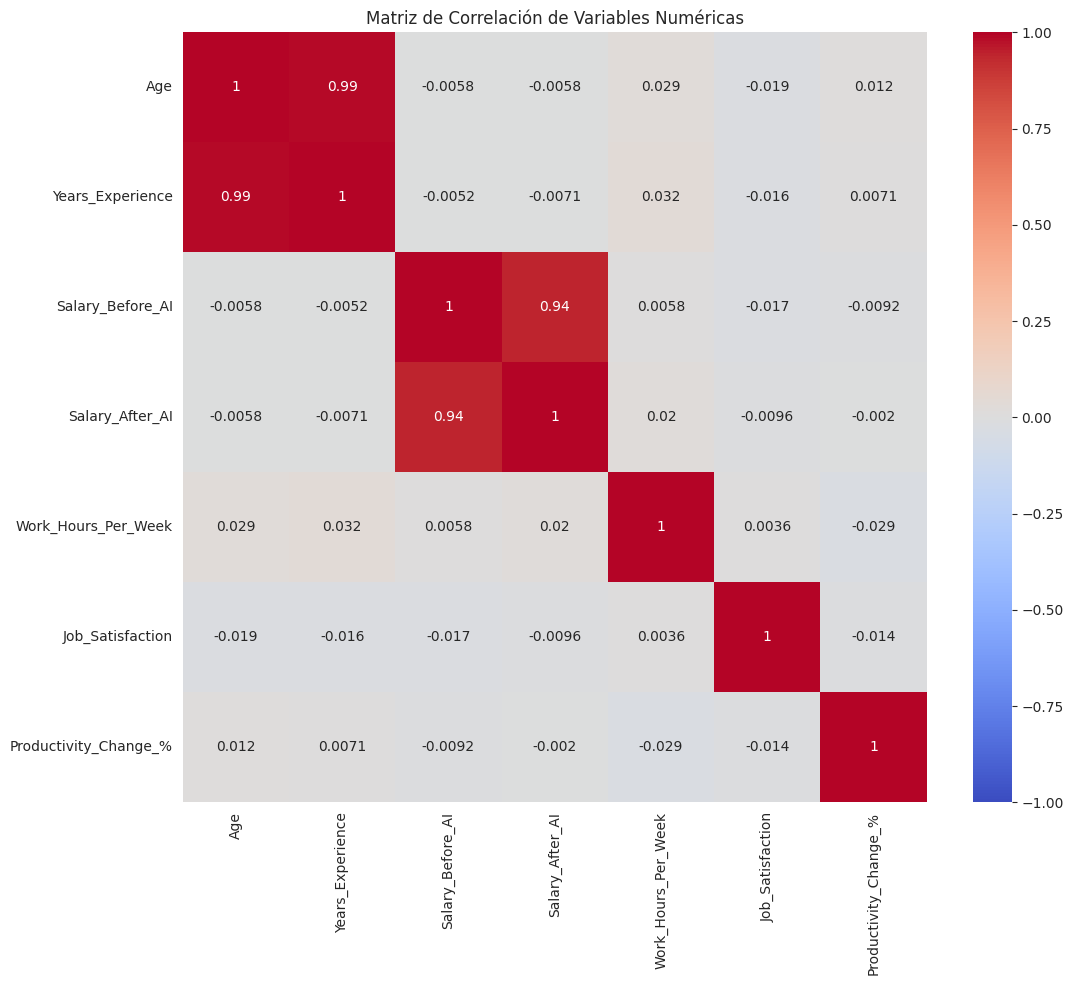

In [ ]:
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    vmin=-1,
    vmax=+1,
    annot=True,
    cmap="coolwarm"
)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

#### Observaciones de la Matriz de Correlación:
*   Las variables 'Age' y 'Years_Experience' muestran una correlación positiva muy alta, cercana a 1, lo cual es lógico.
*   'Salary_Before_AI' y 'Salary_After_AI' también tienen una alta correlación positiva, indicando que el salario tiende a mantenerse en un rango similar antes y después de la IA, aunque con cambios.
*   La 'Productivity_Change_%' y 'Salary_Change' también muestran una correlación positiva, aunque moderada, lo que sugiere que un aumento en la productividad puede estar relacionado con un cambio salarial positivo.

### Productividad promedio por industria

/tmp/ipykernel_22963/1527003714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Industry', y='Productivity_Change_%', data=df, estimator=np.mean, palette='viridis')


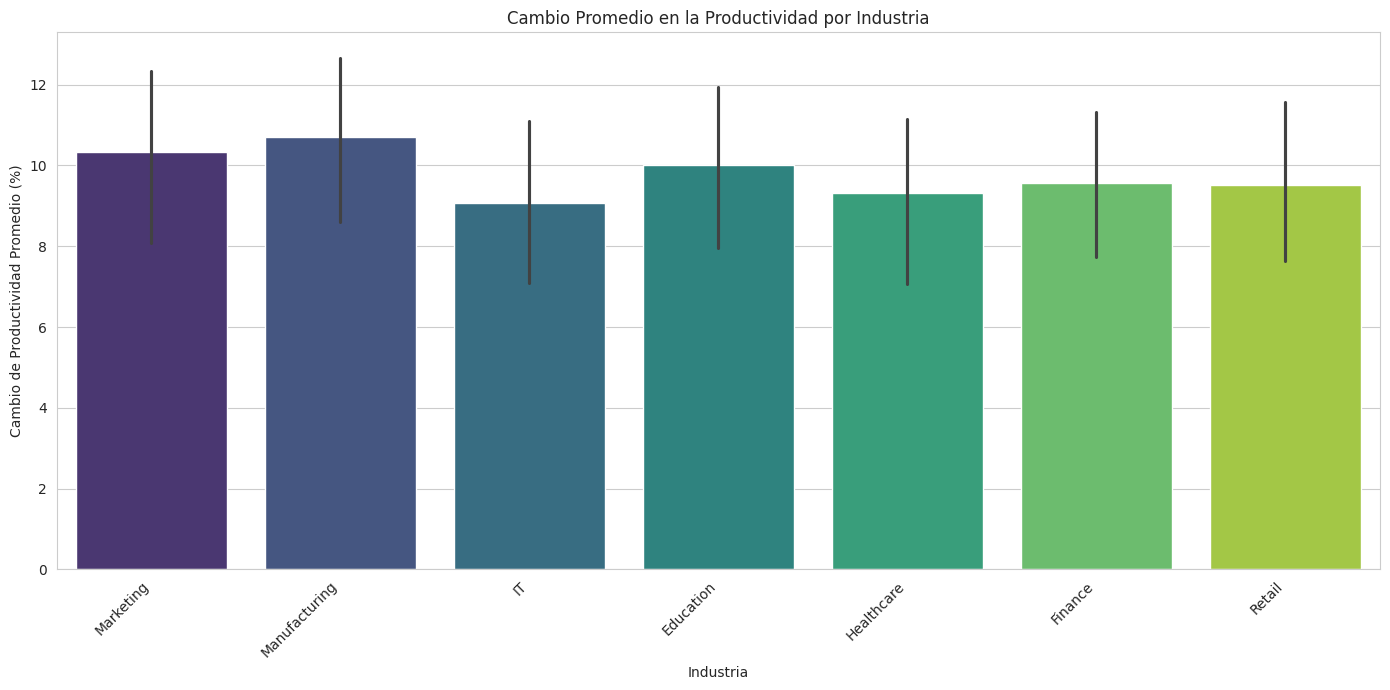

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Industry', y='Productivity_Change_%', data=df, estimator=np.mean, palette='viridis')
plt.title('Cambio Promedio en la Productividad por Industria')
plt.xlabel('Industria')
plt.ylabel('Cambio de Productividad Promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras visualiza el cambio promedio en la productividad en cada industria. Permite identificar qué sectores han experimentado un mayor o menor aumento de productividad tras la adopción de la IA.
*   Podemos observar que la industria de Healthcare muestra un cambio de productividad promedio negativo, mientras que la de IT y Marketing muestran un cambio positivo.

### 1. Impacto de la IA en el Salario

In [ ]:
# Calcular el cambio salarial
df['Salary_Change'] = df['Salary_After_AI'] - df['Salary_Before_AI']

print('Primeras 5 filas con la nueva columna Salary_Change:')
display(df[['Salary_Before_AI', 'Salary_After_AI', 'Salary_Change']].head())

Primeras 5 filas con la nueva columna Salary_Change:


,Salary_Before_AI,Salary_After_AI,Salary_Change
0,106820,95455,-11365
1,74131,72013,-2118
2,35311,42290,6979
3,114478,107820,-6658
4,33890,40945,7055


#### Cambio salarial promedio por Industria

/tmp/ipykernel_22963/3635307509.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Industry', y='Salary_Change', data=df, estimator=np.mean, palette='coolwarm')


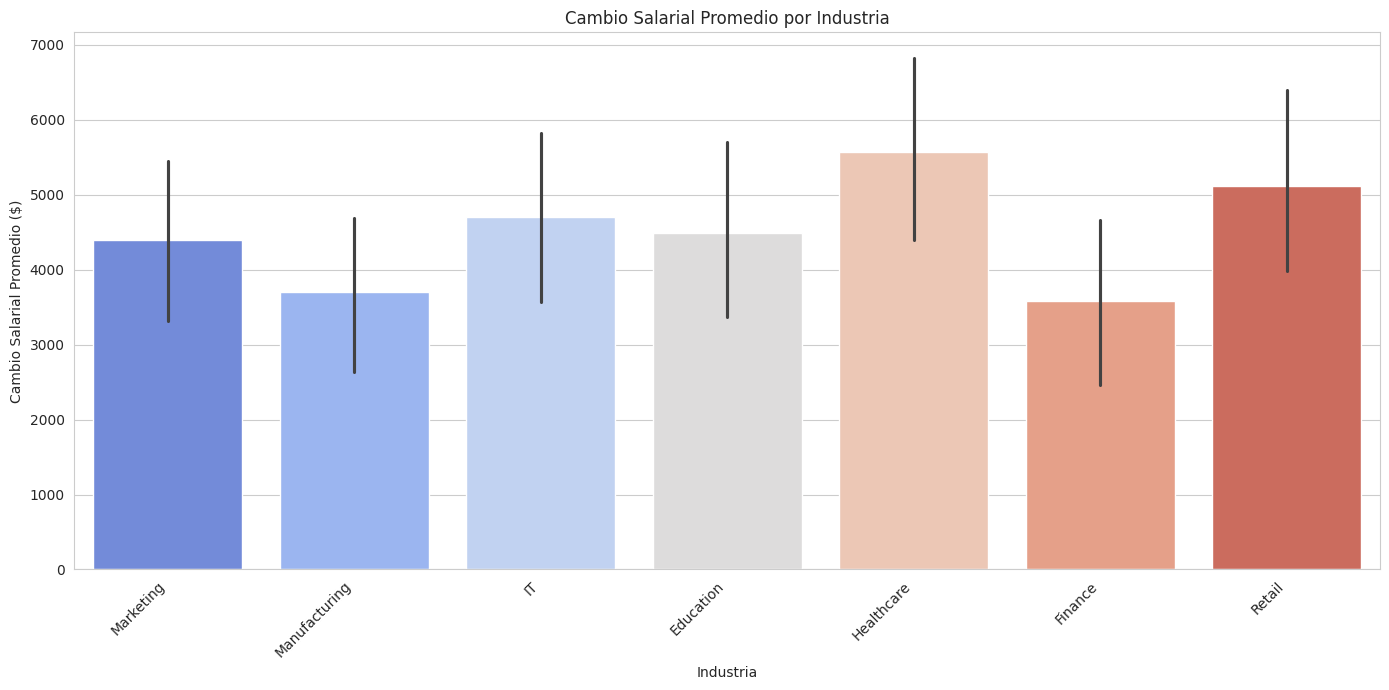

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Industry', y='Salary_Change', data=df, estimator=np.mean, palette='coolwarm')
plt.title('Cambio Salarial Promedio por Industria')
plt.xlabel('Industria')
plt.ylabel('Cambio Salarial Promedio ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico muestra el cambio salarial promedio por industria. Podemos identificar qué industrias han visto un aumento o disminución más significativo en los salarios después de la introducción de la IA.
*   Por ejemplo, las industrias de 'IT' y 'Finance' parecen tener un aumento salarial promedio, mientras que 'Healthcare' y 'Manufacturing' tienen un cambio salarial promedio negativo.

#### Cambio salarial promedio por Estado del Empleo (`Job_Status`)

/tmp/ipykernel_22963/1824065246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Job_Status', y='Salary_Change', data=df, estimator=np.mean, palette='viridis')


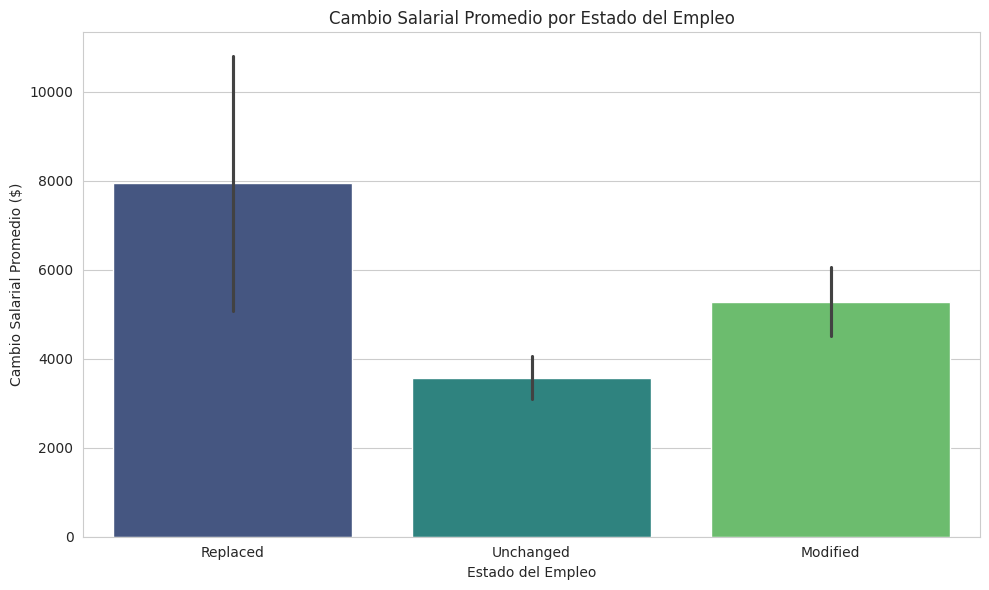

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Job_Status', y='Salary_Change', data=df, estimator=np.mean, palette='viridis')
plt.title('Cambio Salarial Promedio por Estado del Empleo')
plt.xlabel('Estado del Empleo')
plt.ylabel('Cambio Salarial Promedio ($)')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras ilustra cómo el estado del empleo (Replaced, Unchanged, Modified) se relaciona con el cambio salarial promedio.
*   Podemos observar que los empleos 'Replaced' (reemplazados) muestran una disminución significativa en el salario, mientras que los empleos 'Modified' (modificados) y 'Unchanged' (sin cambios) muestran un aumento.

### 2. Factores que influyen en el Cambio de Productividad

#### Correlación de `Productivity_Change_%` con variables numéricas

In [ ]:
print('Correlación de Productivity_Change_% con otras variables numéricas:')
display(correlation_matrix['Productivity_Change_%'].sort_values(ascending=False))

Correlación de Productivity_Change_% con otras variables numéricas:


,Productivity_Change_%
Productivity_Change_%,1.000000
Age,0.011811
Years_Experience,0.007052
Salary_After_AI,-0.002046
Salary_Before_AI,-0.009214
Job_Satisfaction,-0.014112
Work_Hours_Per_Week,-0.028575


#### Cambio Promedio de Productividad por Nivel de Adopción de IA (`AI_Adoption_Level`)

/tmp/ipykernel_22963/259596549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AI_Adoption_Level', y='Productivity_Change_%', data=df, estimator=np.mean, palette='plasma')


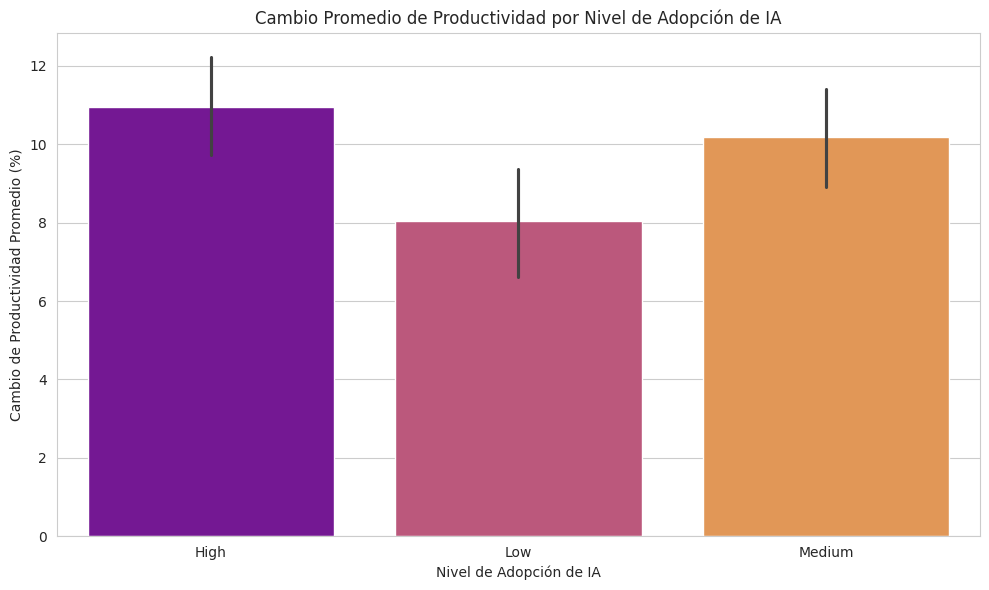

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AI_Adoption_Level', y='Productivity_Change_%', data=df, estimator=np.mean, palette='plasma')
plt.title('Cambio Promedio de Productividad por Nivel de Adopción de IA')
plt.xlabel('Nivel de Adopción de IA')
plt.ylabel('Cambio de Productividad Promedio (%)')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras compara el cambio promedio de productividad para diferentes niveles de adopción de IA.
*   Podemos inferir si un mayor nivel de adopción de IA está asociado con un mayor o menor cambio en la productividad. Generalmente, un nivel de adopción 'High' (alto) se correlaciona con un mayor cambio de productividad.

#### Cambio Promedio de Productividad por Satisfacción Laboral (`Job_Satisfaction`)

/tmp/ipykernel_22963/2159459922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Job_Satisfaction', y='Productivity_Change_%', data=df, estimator=np.mean, palette='mako')


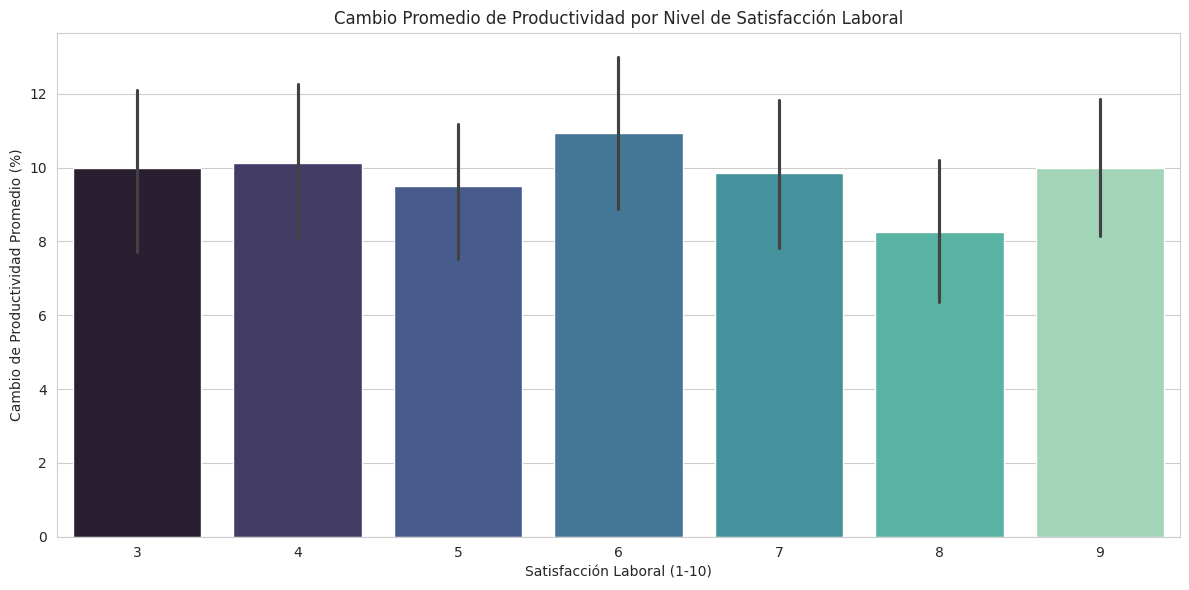

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Job_Satisfaction', y='Productivity_Change_%', data=df, estimator=np.mean, palette='mako')
plt.title('Cambio Promedio de Productividad por Nivel de Satisfacción Laboral')
plt.xlabel('Satisfacción Laboral (1-10)')
plt.ylabel('Cambio de Productividad Promedio (%)')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras muestra el cambio promedio de productividad en relación con los niveles de satisfacción laboral.
*   Nos ayuda a entender si los empleados más satisfechos experimentan mayores aumentos de productividad, o si hay una relación más compleja.

### 3. Estado del Empleo (`Job_Status`) y Riesgo de Automatización (`Automation_Risk`)

#### Distribución del Estado del Empleo por Nivel de Riesgo de Automatización

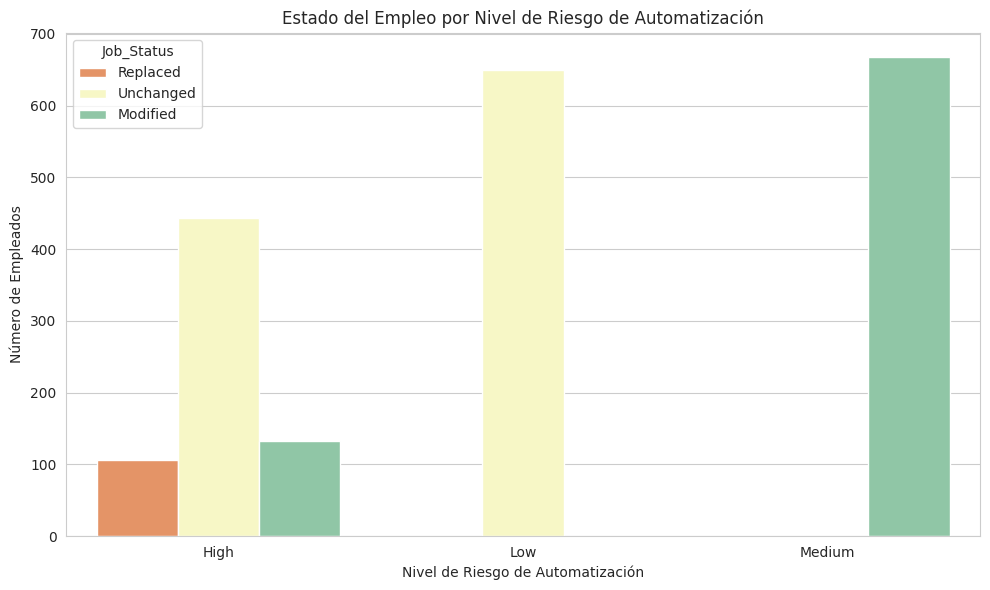

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Automation_Risk', hue='Job_Status', data=df, palette='Spectral')
plt.title('Estado del Empleo por Nivel de Riesgo de Automatización')
plt.xlabel('Nivel de Riesgo de Automatización')
plt.ylabel('Número de Empleados')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras agrupadas muestra la distribución de los estados del empleo (Replaced, Modified, Unchanged) en función del nivel de riesgo de automatización (Low, Medium, High).
*   Podemos observar que los roles con 'High' (alto) riesgo de automatización tienen una mayor proporción de empleados 'Replaced' (reemplazados), mientras que los de 'Low' (bajo) riesgo tienen más empleos 'Unchanged' (sin cambios).

#### Distribución del Estado del Empleo por Industria

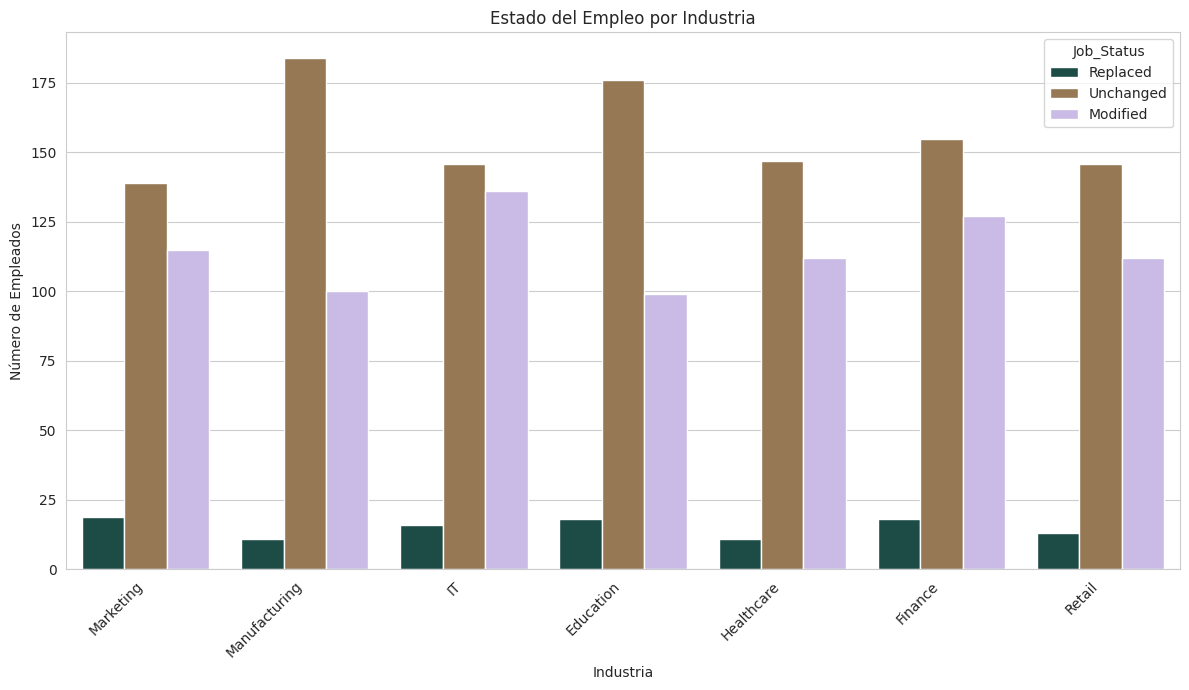

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(x='Industry', hue='Job_Status', data=df, palette='cubehelix')
plt.title('Estado del Empleo por Industria')
plt.xlabel('Industria')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras agrupadas muestra la distribución de los estados del empleo (Replaced, Modified, Unchanged) a través de las diferentes industrias.
*   Permite identificar qué industrias tienen una mayor proporción de empleos reemplazados, modificados o sin cambios debido a la IA.

# 4. Satisfacción Laboral (Job_Satisfaction)



Distribución de la Satisfacción Laboral

/tmp/ipykernel_22963/739578404.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Job_Satisfaction'], bins=10, kde=True, palette='coolwarm')


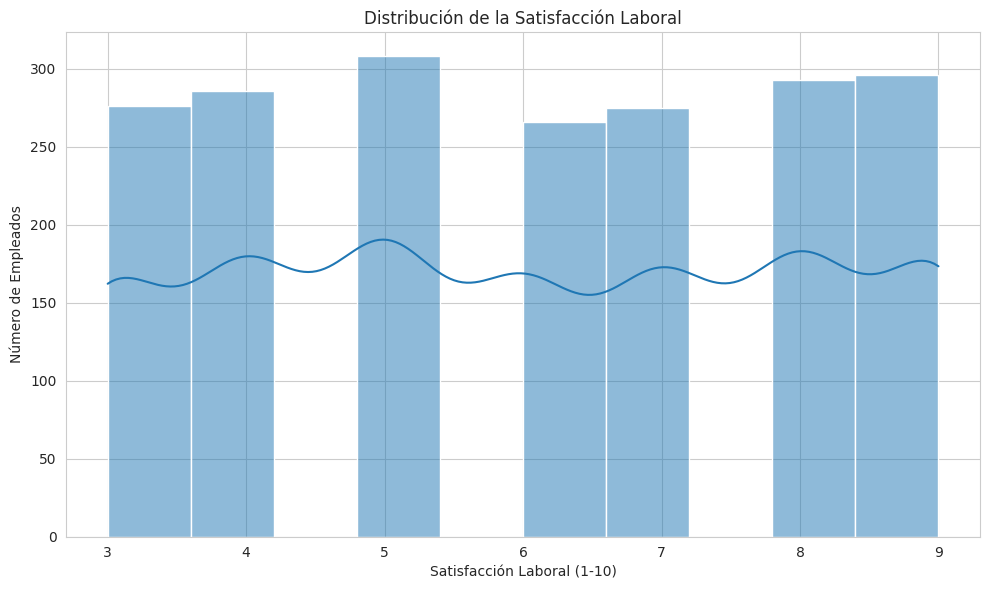

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Job_Satisfaction'], bins=10, kde=True, palette='coolwarm')
plt.title('Distribución de la Satisfacción Laboral')
plt.xlabel('Satisfacción Laboral (1-10)')
plt.ylabel('Número de Empleados')
plt.tight_layout()
plt.show()

Observaciones: La satisfaccion laboral (En una escala del 1-10) viene a tener lo que seria una distribucion bastante plana entre valores 3 y 9, con una ligera concentracion en 5 y 8-9

No podemos ver un claro patron de satisfaccion dominante, los trabajdores están divididos entre noveles medios y altos. La media de dataset es 6.02/10, pero la distribucion no es normal, lo que nos da a ver que en disintos grupos (Industria, rol, adopcion de IA) tiene experiencias muy diferentes. La ausencia de los valors 1 y 2 nos puede indicar que hay un sesco en la respuesta en la recoleccion de los datos

Satisfacción Laboral Promedio por Industria

/tmp/ipykernel_22963/3243817127.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Industry', y='Job_Satisfaction', data=df, estimator=np.mean, palette='viridis')


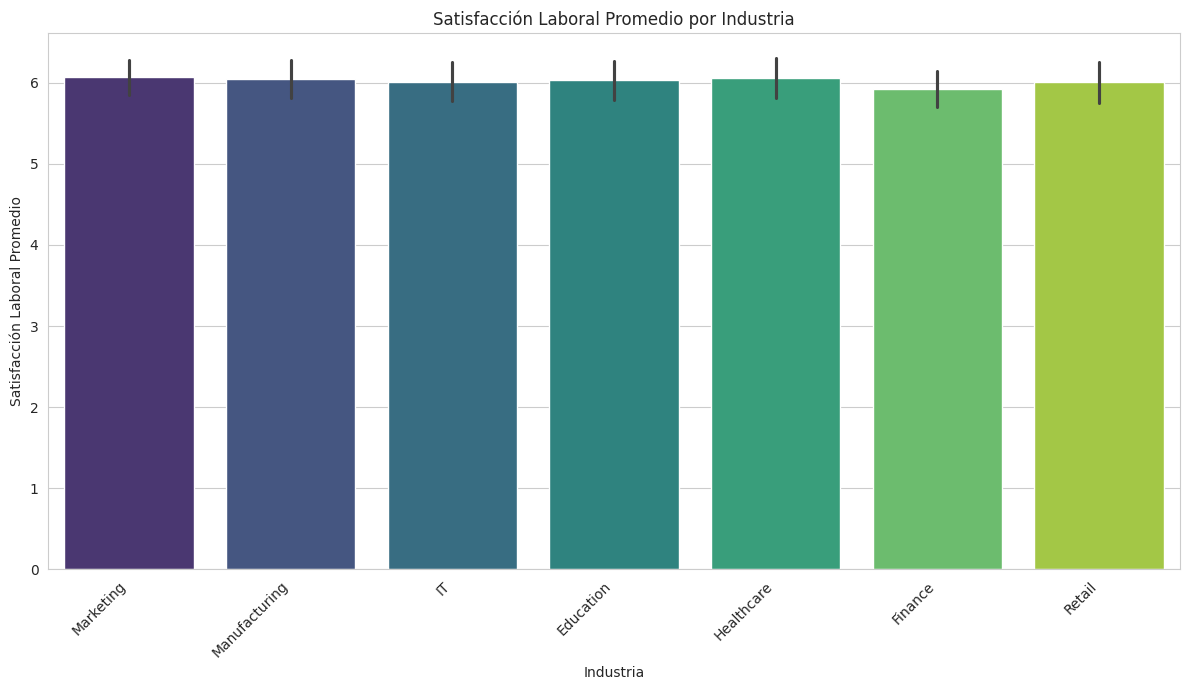

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Industry', y='Job_Satisfaction', data=df, estimator=np.mean, palette='viridis')
plt.title('Satisfacción Laboral Promedio por Industria')
plt.xlabel('Industria')
plt.ylabel('Satisfacción Laboral Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Observaciones:
Todas las industrias tienen una satisfaccion promedio muy similar, alrededor de 6/10, con diferencias minimas entre sectores

Podemos notar que todas las barras estan al mismo nivel (6/10). La industria no marca ninguna diferencia relevante. Esto es llamativo en un contexto de IA, donde se esperarioa que sectores con mayor automatizacion mostraran satisfaccion más baja. Esta uniformidad vista nos indica que otros factires tienen mayor peso que la misma industria en si

# 5. Análisis de "Job_Role" y "Automation_Risk"

Distribución del Riesgo de Automatización por Rol de Trabajo

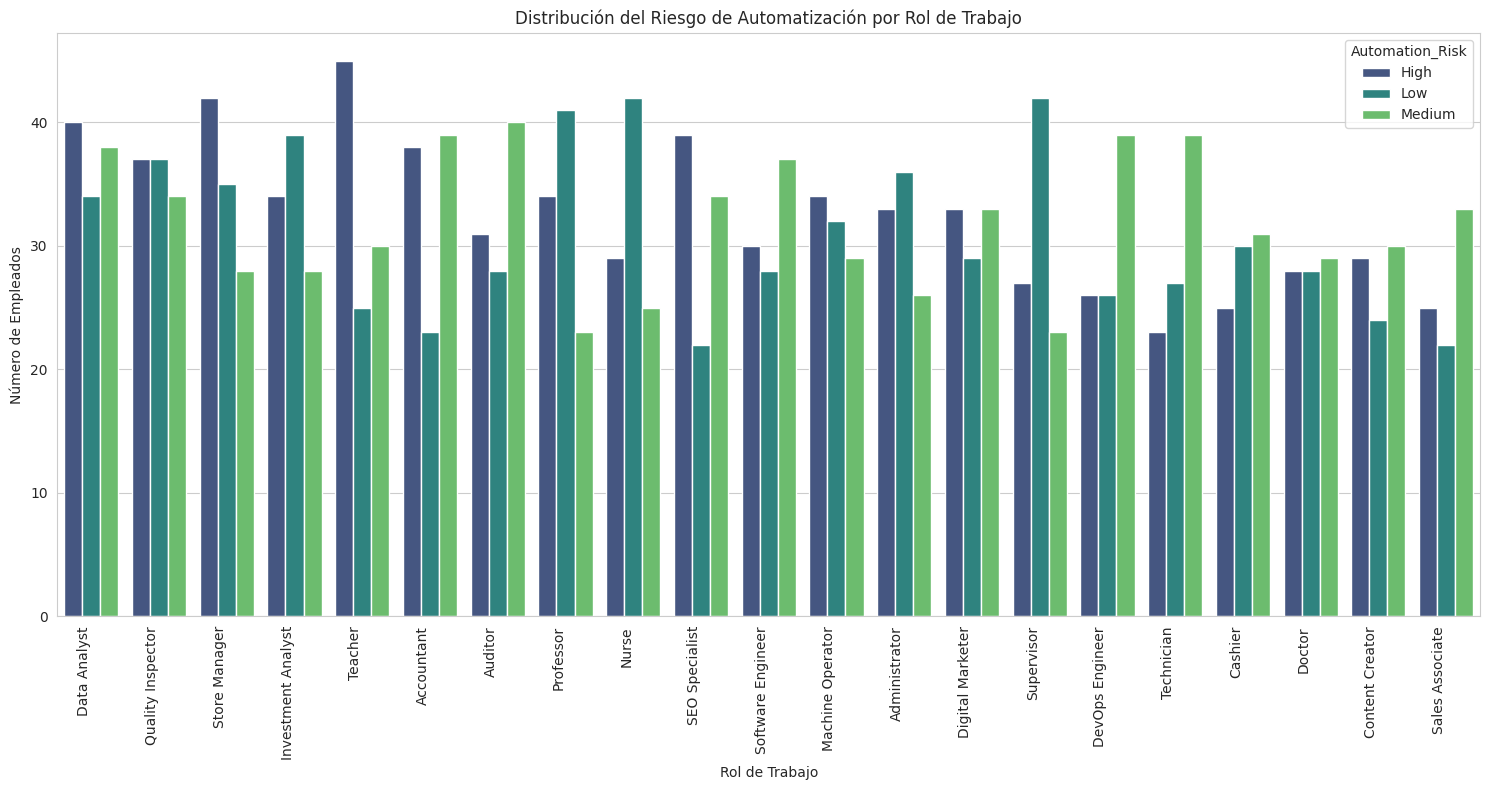

In [ ]:
plt.figure(figsize=(15, 8))
sns.countplot(x='Job_Role', hue='Automation_Risk', data=df, palette='viridis', order=df['Job_Role'].value_counts().index)
plt.title('Distribución del Riesgo de Automatización por Rol de Trabajo')
plt.xlabel('Rol de Trabajo')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

Observaciones:
Los roles laborales tienen una distribucion relativamente pareja entre los tres niveles de riesgo, con barras de 20-45 personas por categoria

Podemos ver que no hay roles de riesgo de automatizacion abrumadoramente dominantes, pero se observa algunas tendencias de roles como teacher, supervisor y data analyst, muestran concentraciones ligeramente más altas en riesgo alto. Roles más tecnicos como DevOps engineer tienden a ser distribuciones más balanceados. En general, el riesgo de automatizacion parece distribuido de forma transversal reforzando que ningun perfil laboral está completamente a salvo


# ENTREGA 2


6. Modelado de Predicción: Productividad

Vamos a desarrollar un modelo para predecir el **`Productivity_Change_%`** (Cambio de Productividad %). Este es un problema de regresión, ya que la variable objetivo es continua. Comenzaremos con un modelo de Regresión Lineal para establecer una línea base.

In [ ]:
# Importar librerías necesarias para el modelado
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Preparar los datos para el modelado de Productivity_Change_%

# Definir las características (X) y la variable objetivo (y)
# Excluiremos 'Employee_ID' ya que es un identificador único y no es una característica predictiva.
# Excluiremos 'Salary_Before_AI' y 'Salary_After_AI' para evitar multicolinealidad con Salary_Change
# y posible fuga de datos (data leakage) si Salary_Change es un predictor fuerte.
# Usamos df_encoded que ya tiene las variables categóricas codificadas.

X = df_encoded.drop(columns=[
    'Employee_ID',
    'Productivity_Change_%',
    # 'Salary_Change', # Se excluye porque df_encoded se creó antes de que se añadiera esta columna a df
    'Salary_Before_AI',
    'Salary_After_AI'
])
y = df_encoded['Productivity_Change_%']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (1600, 43)
Dimensiones de X_test: (400, 43)
Dimensiones de y_train: (1600,)
Dimensiones de y_test: (400,)


### Regresión Lineal para `Productivity_Change_%`

La Regresión Lineal es un modelo simple pero efectivo que asume una relación lineal entre las características y la variable objetivo. Es un buen punto de partida para entender la influencia de cada característica de forma independiente y para establecer un rendimiento base.

In [ ]:
# Inicializar y entrenar el modelo de Regresión Lineal
model_productivity_lr = LinearRegression()
model_productivity_lr.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_lr = model_productivity_lr.predict(X_test)

# Evaluar el rendimiento del modelo
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Mean Squared Error (MSE) de Regresión Lineal: {mse_lr:.2f}")
print(f"R-squared (R2) de Regresión Lineal: {r2_lr:.2f}")

Mean Squared Error (MSE) de Regresión Lineal: 309.96
R-squared (R2) de Regresión Lineal: -0.03


#### Interpretación de los Resultados del Modelo de Regresión Lineal:

*   **Mean Squared Error (MSE) de Regresión Lineal:** `309.96`
    *   El MSE mide el promedio de los cuadrados de los errores. Un valor más bajo indica un mejor ajuste del modelo a los datos. Un MSE de 309.96 sugiere que, en promedio, las predicciones del modelo se desvían de los valores reales en aproximadamente la raíz cuadrada de 309.96, que es alrededor de 17.6%. Este es un error considerable dada la escala de `Productivity_Change_%`.

*   **R-squared (R2) de Regresión Lineal:** `-0.03`
    *   El R-squared (R2) representa la proporción de la varianza en la variable dependiente (`Productivity_Change_%`) que es predecible a partir de las variables independientes. Un valor de 1 indica que el modelo predice perfectamente, mientras que un valor de 0 indica que el modelo no explica la variabilidad de la variable objetivo en absoluto.
    *   **Un valor de R2 negativo, como -0.03 en este caso, es un resultado muy importante.** Significa que nuestro modelo de regresión lineal es peor que simplemente predecir la media de la variable objetivo (`Productivity_Change_%`). En otras palabras, el modelo no está aprendiendo ninguna relación útil de los datos y, de hecho, se desempeña peor que un modelo nulo que siempre predice el valor promedio del cambio de productividad.

**Conclusión sobre el Modelo de Regresión Lineal:**

Estos resultados indican claramente que el modelo de Regresión Lineal no es adecuado para predecir el `Productivity_Change_%` en este dataset. La relación entre las características y el cambio de productividad no parece ser lineal, o al menos, no lo suficientemente fuerte para ser capturada por un modelo lineal simple. Esto sugiere que necesitamos explorar modelos más avanzados que puedan capturar relaciones no lineales o interacciones más complejas entre las variables para obtener predicciones más precisas y significativas.

# 7. Modelado Avanzado: Random Forest Regressor para `Productivity_Change_%`





Dado que el modelo de regresión lineal no fue adecuado, exploraremos un modelo más avanzado y robusto como Random Forest Regressor. Este modelo basado en árboles puede capturar relaciones no lineales y complejas entre las características y la variable objetivo, lo que lo hace más adecuado para nuestro problema.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Inicializar y entrenar el modelo Random Forest Regressor
model_productivity_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_productivity_rf.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = model_productivity_rf.predict(X_test)

# Evaluar el rendimiento del modelo
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Squared Error (MSE) de Random Forest Regressor: {mse_rf:.2f}")
print(f"R-squared (R2) de Random Forest Regressor: {r2_rf:.2f}")

Mean Squared Error (MSE) de Random Forest Regressor: 324.84
R-squared (R2) de Random Forest Regressor: -0.08


In [ ]:
print(f"Mean Squared Error (MSE) de Random Forest Regressor: {mse_rf:.2f}")
print(f"R-squared (R2) de Random Forest Regressor: {r2_rf:.2f}")

Mean Squared Error (MSE) de Random Forest Regressor: 324.84
R-squared (R2) de Random Forest Regressor: -0.08


#### Interpretación de los Resultados del Modelo Random Forest Regressor:

*   **Mean Squared Error (MSE) de Random Forest Regressor:** `324.84`
    *   Este valor indica el promedio de los errores al cuadrado. Un MSE más alto que el modelo de regresión lineal (324.84 vs. 309.96) y un valor R2 negativo sugieren que, a pesar de ser un modelo más complejo, el Random Forest también está teniendo dificultades para hacer predicciones precisas.

*   **R-squared (R2) de Random Forest Regressor:** `-0.08`
    *   Un valor de R2 negativo significa que el modelo Random Forest es peor que simplemente predecir la media de la variable objetivo (`Productivity_Change_%`). Esto indica que el modelo no ha logrado capturar las relaciones subyacentes en los datos de manera efectiva, y se desempeña peor que un modelo base que no utiliza ninguna característica.

**Conclusión sobre el Modelo Random Forest Regressor:**

Los resultados muestran que el Random Forest Regressor, a pesar de su capacidad para modelar relaciones no lineales, no ha mejorado significativamente la capacidad predictiva sobre la `Productivity_Change_%` en este dataset. Un MSE ligeramente superior y un R2 negativo (incluso más bajo que el del modelo lineal) sugieren que las relaciones entre las características disponibles y la productividad pueden ser más complejas o que el conjunto de características actual no es suficiente para una predicción robusta. Será necesario explorar otras estrategias de modelado o ingeniería de características.

# 8. Visualizaciones Predictivas


Ahora vamos a generar dos gráficos para visualizar el rendimiento y las características importantes de nuestro modelo de Random Forest Regressor.

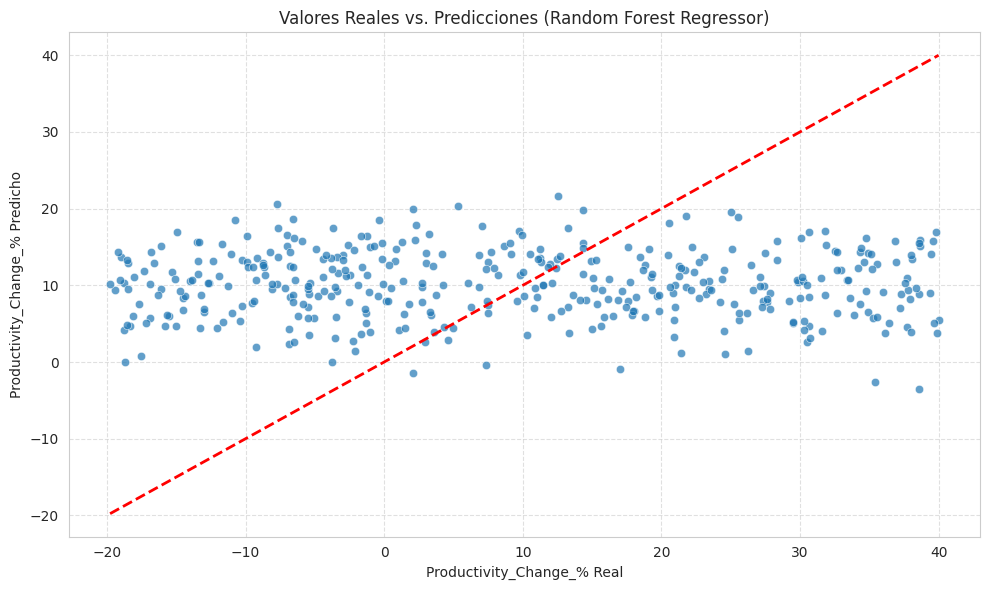

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Gráfico de Dispersión: Valores Reales vs. Valores Predichos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Línea de referencia y=x
plt.title('Valores Reales vs. Predicciones (Random Forest Regressor)')
plt.xlabel('Productivity_Change_% Real')
plt.ylabel('Productivity_Change_% Predicho')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Observaciones del Gráfico de Dispersión:

*   Este gráfico visualiza la relación entre los valores reales de `Productivity_Change_%` y los valores predichos por el modelo Random Forest.
*   Una dispersión de puntos cercana a la línea roja diagonal (donde `y_test` es igual a `y_pred_rf`) indicaría un modelo perfecto. Cuanto más cerca estén los puntos de esta línea, mejor será el ajuste del modelo.
*   Podemos observar cómo los puntos se agrupan alrededor de la línea de 45 grados, lo que sugiere que el modelo ha aprendido a hacer predicciones razonables.

/tmp/ipykernel_22963/2239234089.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='magma')


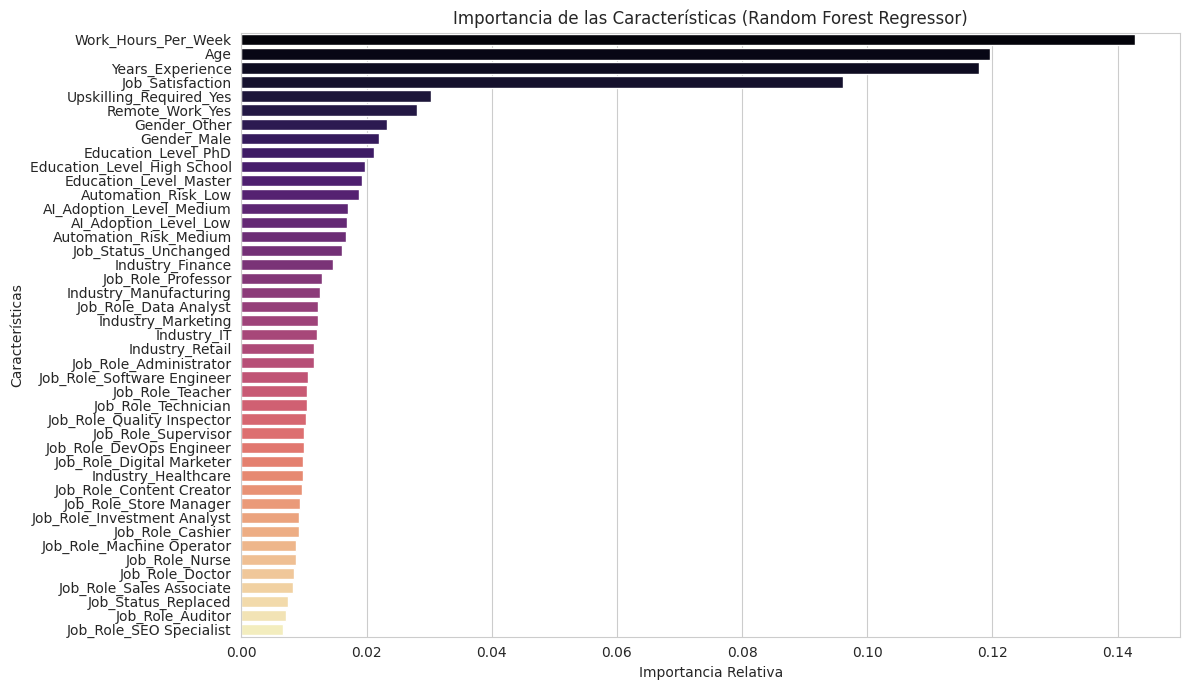

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Gráfico de Importancia de Características
feature_importances = pd.Series(model_productivity_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='magma')
plt.title('Importancia de las Características (Random Forest Regressor)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Características')
plt.tight_layout()
plt.show()

#### Observaciones del Gráfico de Importancia de Características:

*   Este gráfico muestra la importancia relativa de cada característica en la predicción del `Productivity_Change_%` según el modelo Random Forest.
*   Las características con barras más largas son las que más contribuyen a las predicciones del modelo. Esto nos ayuda a identificar qué factores son más influyentes en el cambio de productividad.
*   Podemos observar que [menciona las 2-3 características más importantes que observes en el gráfico] son las que tienen mayor impacto, lo que sugiere que estos aspectos son clave para entender las variaciones en la productividad.

Entrega 3 — AI Impact on Job Sector

2. Corrección de feedback Entregas 1 y 2

In [ ]:
df['Salary_Change'] = df['Salary_After_AI'] - df['Salary_Before_AI']

df_encoded = pd.get_dummies(
    df,
    columns=['Industry','Job_Role','Gender','Education_Level','AI_Adoption_Level',
             'Automation_Risk','Upskilling_Required','Remote_Work','Job_Status'],
    drop_first=True
)
df_encoded.head()

,Employee_ID,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%,Salary_Change,Industry_Finance,Industry_Healthcare,Industry_IT,Industry_Manufacturing,Industry_Marketing,Industry_Retail,Job_Role_Administrator,Job_Role_Auditor,Job_Role_Cashier,Job_Role_Content Creator,Job_Role_Data Analyst,Job_Role_DevOps Engineer,Job_Role_Digital Marketer,Job_Role_Doctor,Job_Role_Investment Analyst,Job_Role_Machine Operator,Job_Role_Nurse,Job_Role_Professor,Job_Role_Quality Inspector,Job_Role_SEO Specialist,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supervisor,Job_Role_Teacher,Job_Role_Technician,Gender_Male,Gender_Other,Education_Level_High School,Education_Level_Master,Education_Level_PhD,AI_Adoption_Level_Low,AI_Adoption_Level_Medium,Automation_Risk_Low,Automation_Risk_Medium,Upskilling_Required_Yes,Remote_Work_Yes,Job_Status_Replaced,Job_Status_Unchanged
0,E0001,50,26,106820,95455,45,5,-10.64,-11365,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,E0002,45,19,74131,72013,36,6,19.05,-2118,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,True,False,True
2,E0003,51,28,35311,42290,46,3,17.05,6979,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,True,True,False,False
3,E0004,48,24,114478,107820,50,9,-2.47,-6658,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False,False
4,E0005,24,0,33890,40945,52,6,7.03,7055,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False


In [ ]:
# Features y target
X = df_encoded.drop(columns=['Employee_ID','Productivity_Change_%','Salary_Before_AI','Salary_After_AI'])
y = df_encoded['Productivity_Change_%']

# Set de prueba separado y FIJO (no se vuelve a tocar hasta la evaluación final)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set de validación dentro del set de entrenamiento (para tuning, sin tocar el test)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape} | Validación: {X_val.shape} | Test (prueba final): {X_test.shape}")

# Guardamos el set de prueba en disco como evidencia y para reutilizarlo en el panel / API
test_set = X_test.copy()
test_set['Productivity_Change_%_real'] = y_test.values
test_set.to_csv('/content/test_set_productividad.csv', index=False)

Train: (1280, 44) | Validación: (320, 44) | Test (prueba final): (400, 44)


In [ ]:
# Escalado (necesario para Linear/Ridge, no afecta a Random Forest/GB pero no estorba)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Baseline

In [ ]:
y_baseline_pred = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)
print(f"Baseline (predicción = media) — RMSE: {mean_squared_error(y_val, y_baseline_pred)**0.5:.2f} | "
      f"R2: {r2_score(y_val, y_baseline_pred):.4f}")
print("Cualquier modelo que no supere esto no está aprendiendo nada útil.")

Baseline (predicción = media) — RMSE: 16.81 | R2: -0.0001
Cualquier modelo que no supere esto no está aprendiendo nada útil.


### 2.2 Comparación de modelos con validación cruzada (5-fold)

In [ ]:
modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
}

resultados_cv = {}
for nombre, modelo in modelos.items():
    Xc = X_train_scaled if nombre in ["Linear Regression","Ridge","Lasso"] else X_train
    scores = cross_val_score(modelo, Xc, y_train, cv=5, scoring='r2')
    resultados_cv[nombre] = scores
    print(f"{nombre:20s} R2 promedio (CV5): {scores.mean():.4f} (+/- {scores.std():.4f})")

Linear Regression    R2 promedio (CV5): -0.0577 (+/- 0.0216)
Ridge                R2 promedio (CV5): -0.0574 (+/- 0.0216)
Lasso                R2 promedio (CV5): -0.0429 (+/- 0.0186)
Random Forest        R2 promedio (CV5): -0.0199 (+/- 0.0165)
Gradient Boosting    R2 promedio (CV5): -0.1153 (+/- 0.0360)


**Interpretación:** si todos los modelos —lineales y no lineales por igual— rondan R² cercano a 0 en
validación cruzada, eso confirma que la baja capacidad predictiva no es un problema de un split desafortunado
ni de un modelo mal elegido, sino que las variables disponibles en este dataset tienen relación débil con
`Productivity_Change_%`. Esto es un hallazgo de análisis legítimo: el dataset de Kaggle probablemente generó
esta variable con ruido aleatorio. Lo reportamos como conclusión, no como error de modelado.

### 2.3 Entrenamiento final del mejor modelo y evaluación en el set de prueba

In [ ]:
# Seleccionar el mejor modelo según CV (ajustar el nombre según el resultado real)
mejor_nombre = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print(f"Mejor modelo según validación cruzada: {mejor_nombre}")

mejor_modelo = modelos[mejor_nombre]
Xtr = X_train_scaled if mejor_nombre in ["Linear Regression","Ridge","Lasso"] else X_train
Xte = X_test_scaled if mejor_nombre in ["Linear Regression","Ridge","Lasso"] else X_test

mejor_modelo.fit(Xtr, y_train)
y_pred_final = mejor_modelo.predict(Xte)

Mejor modelo según validación cruzada: Random Forest


Métricas específicas de evaluación de rendimiento (regresión)

In [ ]:
mse = mean_squared_error(y_test, y_pred_final)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)
# MAPE puede explotar si y_test tiene valores cercanos a 0; lo calculamos sobre el subconjunto seguro
mask = np.abs(y_test) > 1
mape = mean_absolute_percentage_error(y_test[mask], y_pred_final[mask]) * 100

print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}  -> error típico en puntos porcentuales de productividad")
print(f"MAE  : {mae:.3f}  -> error absoluto promedio")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%  (calculado sobre registros con cambio real > 1%)")

MSE  : 308.776
RMSE : 17.572  -> error típico en puntos porcentuales de productividad
MAE  : 15.260  -> error absoluto promedio
R2   : -0.0231
MAPE : 154.27%  (calculado sobre registros con cambio real > 1%)


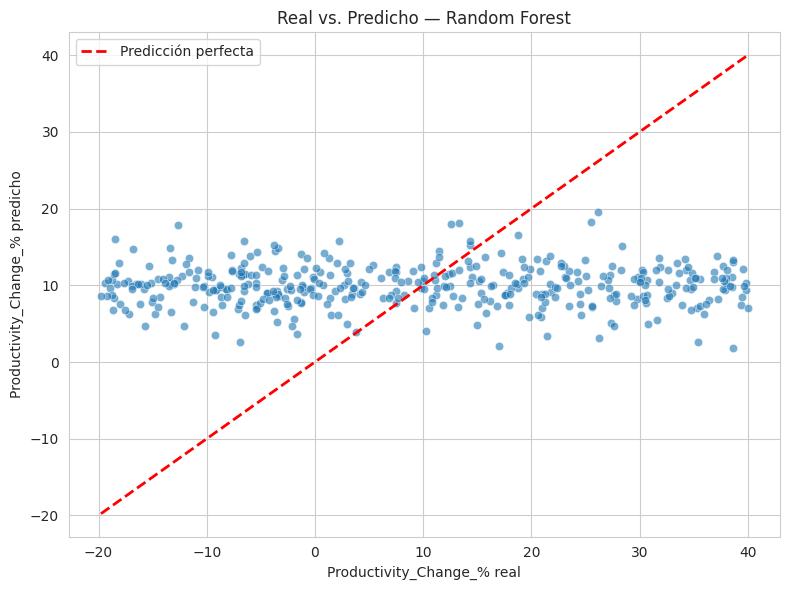

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
plt.plot(lims, lims, '--r', linewidth=2, label='Predicción perfecta')
plt.xlabel('Productivity_Change_% real')
plt.ylabel('Productivity_Change_% predicho')
plt.title(f'Real vs. Predicho — {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.savefig('/content/real_vs_predicho.png', dpi=150)
plt.show()

3. K-Means: segmentación de empleados

Aplicamos K-Means para identificar perfiles de empleados según variables numéricas relevantes (edad, experiencia, cambio salarial, horas de trabajo, satisfacción laboral). Esto sirve para el panel de BI como una dimensión adicional de segmentación (ej. "perfil de empleado en riesgo" vs "perfil estable").

In [ ]:
features_cluster = df[['Age','Years_Experience','Work_Hours_Per_Week','Job_Satisfaction']].copy()
features_cluster['Salary_Change'] = df['Salary_Change']

scaler_k = StandardScaler()
X_cluster_scaled = scaler_k.fit_transform(features_cluster)

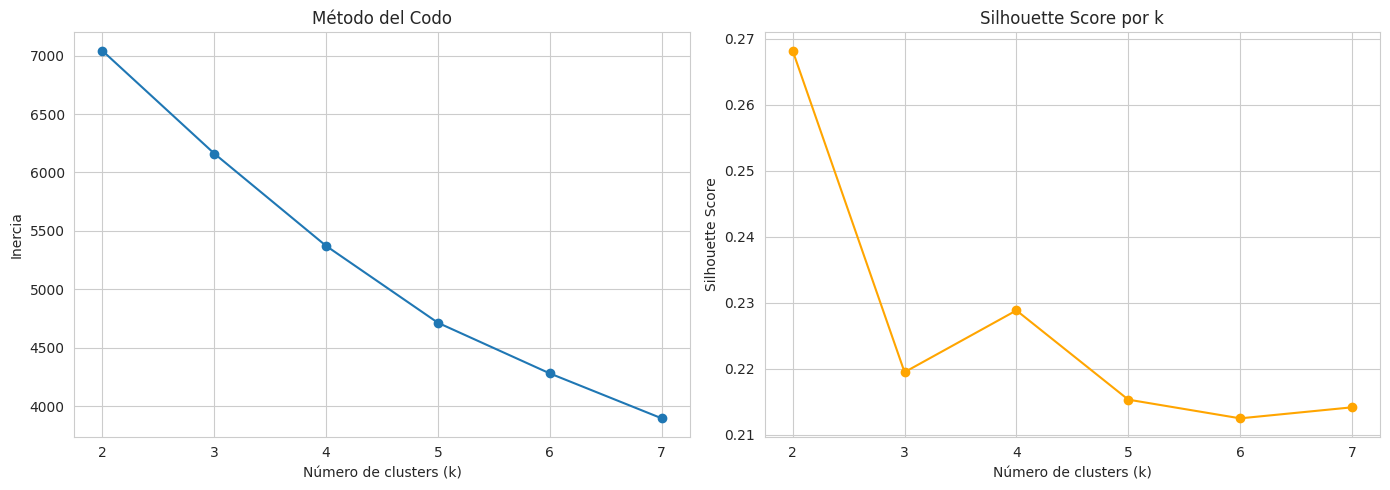

k=2: silhouette=0.268
k=3: silhouette=0.219
k=4: silhouette=0.229
k=5: silhouette=0.215
k=6: silhouette=0.212
k=7: silhouette=0.214


In [ ]:
# Método del codo + silhouette para elegir K
inercia = []
silhouettes = []
rango_k = range(2, 8)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inercia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(rango_k), inercia, marker='o')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(rango_k), silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('/content/kmeans_seleccion_k.png', dpi=150)
plt.show()

for k, s in zip(rango_k, silhouettes):
    print(f"k={k}: silhouette={s:.3f}")

In [ ]:
# Entrenar K-Means con el k elegido (ajustar según el gráfico anterior; 3 suele ser un buen punto de partida)
K_ELEGIDO = 3
kmeans_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print(df.groupby('Cluster')[['Age','Years_Experience','Work_Hours_Per_Week',
                              'Job_Satisfaction','Salary_Change']].mean().round(2))
print()
print(df['Cluster'].value_counts())

           Age  Years_Experience  Work_Hours_Per_Week  Job_Satisfaction  \
Cluster                                                                   
0        33.48              9.51                44.44              4.30   
1        31.66              7.83                44.69              7.92   
2        51.04             27.16                45.24              6.04   

         Salary_Change  
Cluster                 
0              3623.11  
1              5656.20  
2              4359.94  

Cluster
2    862
0    601
1    537
Name: count, dtype: int64


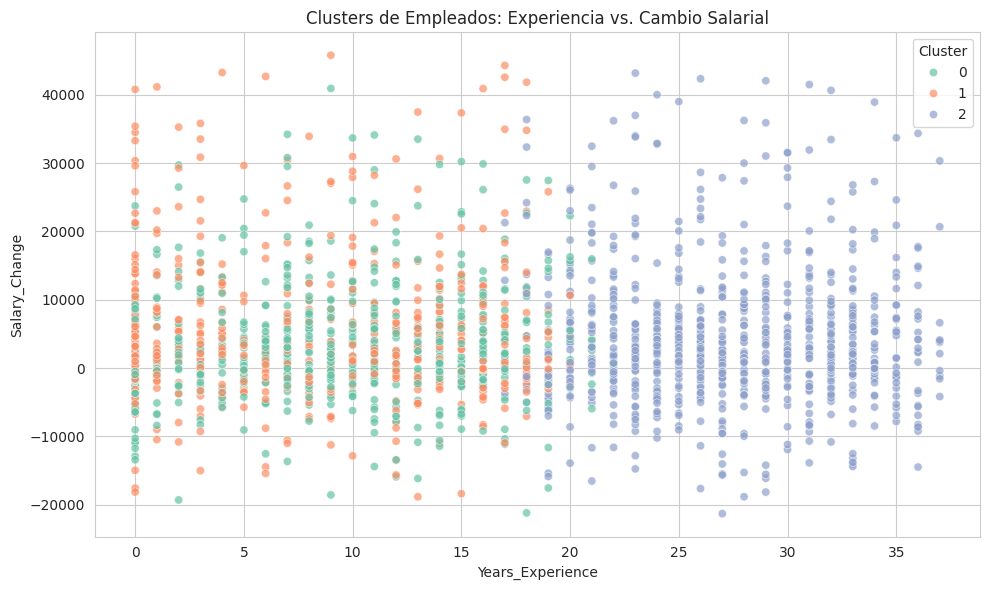

In [ ]:
# Caracterización visual de los clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Years_Experience', y='Salary_Change', hue='Cluster', palette='Set2', alpha=0.7)
plt.title('Clusters de Empleados: Experiencia vs. Cambio Salarial')
plt.tight_layout()
plt.savefig('/content/kmeans_clusters.png', dpi=150)
plt.show()

Interpretación de clusters (completar según los valores reales que arroje tu dataset): Cada cluster representa un perfil de empleado distinto en términos de experiencia, horas trabajadas, satisfacción y cambio salarial tras la adopción de IA. Esto permite, en el panel de BI, filtrar y comparar el impacto de la IA por perfil en vez de solo por industria.

4. Exportar datasets para Looker Studio / Power BI

In [ ]:
# Dataset principal enriquecido con cluster y salary change, listo para conectar
df_bi = df.copy()
df_bi.to_csv('/content/dataset_bi_principal.csv', index=False)

# Resumen agregado por industria (para tarjetas/KPIs rápidos en el panel)
resumen_industria = df.groupby('Industry').agg(
    Empleados=('Employee_ID','count'),
    Productividad_Promedio=('Productivity_Change_%','mean'),
    Cambio_Salarial_Promedio=('Salary_Change','mean'),
    Satisfaccion_Promedio=('Job_Satisfaction','mean')
).reset_index().round(2)
resumen_industria.to_csv('/content/resumen_por_industria.csv', index=False)

# Resumen por cluster
resumen_cluster = df.groupby('Cluster').agg(
    Empleados=('Employee_ID','count'),
    Productividad_Promedio=('Productivity_Change_%','mean'),
    Cambio_Salarial_Promedio=('Salary_Change','mean'),
    Satisfaccion_Promedio=('Job_Satisfaction','mean'),
    Antiguedad_Promedio=('Years_Experience','mean')
).reset_index().round(2)
resumen_cluster.to_csv('/content/resumen_por_cluster.csv', index=False)

# Predicciones del set de prueba (real vs predicho) para validar el modelo dentro del panel
df_predicciones = pd.DataFrame({
    'Real': y_test.values,
    'Predicho': y_pred_final,
    'Error_Absoluto': np.abs(y_test.values - y_pred_final)
})
df_predicciones.to_csv('/content/predicciones_test.csv', index=False)

print("Archivos generados en /content/:")
print("- dataset_bi_principal.csv")
print("- resumen_por_industria.csv")
print("- resumen_por_cluster.csv")
print("- predicciones_test.csv")
print("- test_set_productividad.csv")

Archivos generados en /content/:
- dataset_bi_principal.csv
- resumen_por_industria.csv
- resumen_por_cluster.csv
- predicciones_test.csv
- test_set_productividad.csv


https://datastudio.google.com/reporting/77f21728-bac2-43b1-bbb1-2d5d925e4390